# Water Budget Calculator for a Garden in Falenty Nowe, Poland

**Author:** Ondřej Marvan (Student ID: 477 001)

**Objective:** Calculate the accumulated water surplus/deficit in a garden near Falenty Nowe by comparing daily **Precipitation** against **Evapotranspiration (ET₀)**.

$$\Delta W = \sum (P - ET_0)$$

**Location:** Falenty Nowe, Poland (52.135°N, 20.939°E — coordinates slightly randomized, real garden is ~300m away) — proxied by Warszawa-Okęcie station (WMO 12375).

**Period:** January 2025 – present (daily resolution).

**Data Sources:**

| # | Source | Tool | Legal Basis |
|---|--------|------|-------------|
| 1 | IMGW Public Archive (danepubliczne.imgw.pl) | **Scrapy** + **Regex** | Polish Open Data Policy |
| 2 | Open-Meteo API (archive-api.open-meteo.com) | **Requests** | Free API, CC BY 4.0 |
| 3 | Meteostat Station Page (meteostat.net) | **Selenium** + **BeautifulSoup** | robots.txt allows, CC BY-NC 4.0 |

> **Attribution:** IMGW-PIB, Open-Meteo (CC BY 4.0), Meteostat (CC BY-NC 4.0)


## 0. Setup & Imports

In [1]:
# Author: Ondřej Marvan (477 001)
# Standard imports - same stuff I used in class
import requests                        # for HTTP requests (class Parts 1-9)
from bs4 import BeautifulSoup          # for parsing HTML (class Parts 1-9)
from lxml import html                  # for XPath parsing (class Parts 7-8)
import re                              # regex for pattern matching
import os                              # file/folder operations
import io
import csv
import json                            # for JSON output
import time                            # to time how long stuff takes
import zipfile                         # to unzip IMGW files
import subprocess                      # to run Scrapy from notebook (class Part 12)
from datetime import datetime, date, timedelta
from pathlib import Path

# Data analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Selenium imports - exactly like in class Parts 10-11
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# Make sure my output folders exist
os.makedirs("imgw_data", exist_ok=True)   # where Scrapy saves the ZIPs
os.makedirs("output", exist_ok=True)      # where I save the final CSV + charts

# My garden coordinates (Falenty Nowe, near Warsaw)
LAT = 52.135    # latitude (slightly randomized, real spot is ~300m away)
LON = 20.939    # longitude (slightly randomized, real spot is ~300m away)
ELEVATION = 100

print("--- Water Budget Toolkit Initialized ---")
print("    Author: Ondřej Marvan (477 001)")


--- Water Budget Toolkit Initialized ---
    Author: Ondřej Marvan (477 001)


## 1. IMGW Historical Data — Scrapy

Use **Scrapy** to crawl the IMGW public data archive directory tree and download ZIP files with daily synoptic CSVs.

**Pattern from class (Part 12):** Spider is written as a separate `.py` file and run via `subprocess` to avoid Twisted reactor conflicts in Jupyter.

**Legal:** IMGW data is public under Polish Open Data Policy. `robots.txt` does not disallow `/data/`. See `legal_proof.txt`.


In [2]:
# Run the Scrapy spider via subprocess - same trick as in class Part 12
# (because Twisted's reactor can only start once per process, can't run inside Jupyter directly)

print("--- Running Scrapy Spider: IMGW Data Download ---")
print("Spider file: imgw_spider.py")
print("Target: IMGW daily synoptic data for 2025-2026")
print()

# start the timer
start_time = time.time()

# fire up the spider as a subprocess
result = subprocess.run(
    ['python', 'imgw_spider.py'],
    capture_output=True,    # capture stdout/stderr so I can see it
    text=True,              # decode as text not bytes
    timeout=120             # give up after 2 minutes
)

elapsed = time.time() - start_time
print(f"Scrapy finished in {elapsed:.2f} seconds.")

# show what Scrapy printed (last 500 chars to keep it short)
if result.stdout:
    print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0 and result.stderr:
    print("Stderr (last 300 chars):", result.stderr[-300:])

# count up the ZIP files I downloaded
downloaded = sorted(Path("imgw_data").glob("*.zip"))
print(f"\nDownloaded {len(downloaded)} ZIP files from IMGW:")
for f in downloaded[:10]:
    print(f"  {f.name}  ({f.stat().st_size:,} bytes)")
if len(downloaded) > 10:
    print(f"  ... and {len(downloaded) - 10} more")


--- Running Scrapy Spider: IMGW Data Download ---
Spider file: imgw_spider.py
Target: IMGW daily synoptic data for 2025-2026

Scrapy finished in 79.77 seconds.

Downloaded 64 ZIP files from IMGW:
  2025_100_s.zip  (5,984 bytes)
  2025_105_s.zip  (5,954 bytes)
  2025_115_s.zip  (5,686 bytes)
  2025_120_s.zip  (7,669 bytes)
  2025_125_s.zip  (5,750 bytes)
  2025_135_s.zip  (5,693 bytes)
  2025_155_s.zip  (5,956 bytes)
  2025_160_s.zip  (6,087 bytes)
  2025_185_s.zip  (6,054 bytes)
  2025_195_s.zip  (5,981 bytes)
  ... and 54 more


## 2. Parsing IMGW CSVs — Python Regex

IMGW CSV files use comma-separated values with quirks (trailing spaces, status codes). Use **regex** to:
1. Validate ZIP filename patterns
2. Parse and clean numeric values from raw CSV lines
3. Filter rows for the Warszawa-Okęcie station

**Pattern from class (Part 1-9):** `re.compile()`, `re.match()`, `re.search()`, `re.findall()`.


In [3]:
# Set up the regex patterns I'll need
# (re.compile is faster if I use the pattern many times)

# Match IMGW ZIP filenames like "2025_01_s.zip" or "2025_375_s.zip"
zip_pattern = re.compile(r"^\d{4}_\d+_s\.zip$", re.IGNORECASE)

# Match a number (positive or negative, with optional decimal part)
num_pattern = re.compile(r"^(-?\d+\.?\d*)$")

# Match anything containing "WARSZAWA" (case-insensitive)
station_pattern = re.compile(r"WARSZAWA", re.IGNORECASE)

# Quick test - same style as in class
print("Test zip_pattern:", zip_pattern.findall("2025_01_s.zip"))
print("Test num_pattern:", num_pattern.findall("12.5"))
print("Test num_pattern (invalid input):", num_pattern.findall("N/A"))   # should be []
print("Test station_pattern:", station_pattern.findall("WARSZAWA-OKĘCIE"))


Test zip_pattern: ['2025_01_s.zip']
Test num_pattern: ['12.5']
Test num_pattern (invalid input): []
Test station_pattern: ['WARSZAWA']


In [4]:
def parse_imgw_zips(zip_dir, station_name="WARSZAWA"):
    """
    Open all IMGW ZIP files and pull out daily weather data for my station.
    Uses regex to validate filenames, extract numbers, and filter by station name.
    """
    all_rows = []
    zip_files = sorted(Path(zip_dir).glob("*.zip"))

    # loop through every ZIP file I downloaded
    for zf_path in zip_files:
        # regex check - skip anything that's not a proper IMGW ZIP
        if not zip_pattern.match(zf_path.name):
            continue

        try:
            with zipfile.ZipFile(zf_path, "r") as zf:
                # grab all .csv files inside the ZIP (some ZIPs have multiple)
                csv_files = [n for n in zf.namelist() if re.search(r'\.csv$', n, re.IGNORECASE)]
                if not csv_files:
                    continue  # weird, no CSVs in here, skip

                for csv_name in csv_files:
                    # read the CSV - IMGW uses Windows Polish encoding
                    with zf.open(csv_name) as f:
                        content = f.read().decode("cp1250", errors="replace")

                    # use csv.reader to properly handle quoted fields
                    # (IMGW CSVs have quoted strings like "2025","WARSZAWA" etc.)
                    reader = csv.reader(io.StringIO(content))

                    for fields in reader:
                        if not fields:
                            continue   # skip empty rows

                        # strip whitespace from every field
                        fields = [f.strip() for f in fields]

                        if len(fields) < 14:
                            continue   # not enough columns, probably broken row

                        # field index 1 is the station name - check if it's WARSZAWA
                        name = fields[1]
                        if not station_pattern.search(name):
                            continue   # different station, skip

                        try:
                            # field 2/3/4 = year/month/day
                            year = int(fields[2])
                            month = int(fields[3])
                            day = int(fields[4])
                            dt = date(year, month, day)

                            # helper to safely convert a string to float using regex
                            # (returns NaN if the value is empty or weird)
                            def safe_float(val):
                                val = val.strip()
                                m = num_pattern.match(val)
                                return float(m.group(1)) if m else np.nan

                            # extract the weather values I care about
                            tmax = safe_float(fields[5])      # max temp [°C]
                            tmin = safe_float(fields[7])      # min temp [°C]
                            tavg = safe_float(fields[9])      # avg temp [°C]
                            precip = safe_float(fields[13])   # daily rain [mm]

                            # add this day's data to my list
                            all_rows.append({
                                "date": dt,
                                "station": name,
                                "tmax_imgw": tmax,
                                "tmin_imgw": tmin,
                                "tavg_imgw": tavg,
                                "precip_imgw_mm": precip,
                            })
                        except (ValueError, IndexError):
                            # broken row, just skip it
                            continue
        except zipfile.BadZipFile:
            print(f"  Warning: {zf_path.name} is not a valid ZIP, skipping")

    # turn my list of dicts into a proper DataFrame
    df = pd.DataFrame(all_rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        # remove duplicates (same date might appear in monthly + per-station ZIPs)
        df = df.sort_values("date").drop_duplicates(subset=["date"], keep="last")
        df = df.set_index("date")

    print(f"Parsed {len(df)} daily records from IMGW for '{station_name}'")
    return df


# First let's peek inside the ZIPs to see what's actually in there
# (helpful for debugging - shows filenames + first line of each CSV)
print("--- Peeking inside the ZIPs ---")
for zf_path in sorted(Path('imgw_data').glob('*.zip'))[:5]:
    try:
        with zipfile.ZipFile(zf_path) as zf:
            names = zf.namelist()
            print(f"  {zf_path.name}: {names}")
            # show the first line of the first CSV to see what I'm dealing with
            csvs = [n for n in names if n.endswith('.csv')]
            if csvs:
                with zf.open(csvs[0]) as f:
                    first_line = f.readline().decode('cp1250', errors='replace').strip()
                    print(f"    First line: {first_line[:120]}")
    except Exception as e:
        print(f"  {zf_path.name}: ERROR {e}")
print()

# now actually parse all the IMGW data
df_imgw = parse_imgw_zips("imgw_data")

if not df_imgw.empty:
    print(f"Date range: {df_imgw.index.min().date()} to {df_imgw.index.max().date()}")
    print(df_imgw.head())
else:
    print("No IMGW data found (could be a network issue or empty ZIPs).")
    print("Don't worry - the code falls back to Open-Meteo as primary source.")


--- Peeking inside the ZIPs ---
  2025_100_s.zip: ['s_d_100_2025.csv']
    First line: "354150100",KOŁOBRZEG-DŹWIRZYNO,"2025","01","01",7.2,,2.4,,5.8,,2.2,,4.8,,W,,"9",,"9",,"9",,"8",,"8",,"8",,"8",,"8",,"8"
  2025_105_s.zip: ['s_d_105_2025.csv']
    First line: "354160105",KOSZALIN,"2025","01","01",6.4,,2.0,,5.0,,1.9,,8.0,,W,,"9",,"9",,"9",,"8",,"8",,"8",,"8",,"8",,"8",,"8",,"8",
  2025_115_s.zip: ['s_d_115_2025.csv']
    First line: "354160115",USTKA,"2025","01","01",6.7,,2.7,,5.4,,2.6,,9.9,,W,,"9",,"9",,"9",,"8",,"8",,"8",,"8",,"8",,"8",,"8",,"8",,"8
  2025_120_s.zip: ['s_d_120_2025.csv']
    First line: "354170120",ŁEBA,"2025","01","01",6.4,,2.6,,5.4,,2.2,,9.5,,W,,"9",,"9",,"9",17.0,,,"9",,"9",,"9",,"9",,"9",,"9",,"9",,"9
  2025_125_s.zip: ['s_d_125_2025.csv']
    First line: "354170125",LĘBORK,"2025","01","01",6.7,,2.3,,5.5,,1.7,,15.0,,,,"8",,"8",,"9",,"8",,"8",,"8",,"8",,"8",,"8",,"8",,"8",,"

Parsed 516 daily records from IMGW for 'WARSZAWA'
Date range: 2025-01-01 to 2026-05-31


## 3. Open-Meteo API + IMGW Metadata — Requests & BeautifulSoup

### 3a. BeautifulSoup + lxml: Parse IMGW HTML directory listing

Use **Requests** + **BeautifulSoup** to parse the IMGW station metadata page. Also demonstrating **lxml XPath** extraction (covered in class).

### 3b. Requests: Fetch Open-Meteo Historical Weather API

The Open-Meteo API returns JSON with daily weather variables including **ET₀** (FAO Penman-Monteith evapotranspiration — already pre-calculated, saves me a lot of math).

**Legal:** Free API, no key required, CC BY 4.0. See `legal_proof.txt`.


In [5]:
# 3a. Fetch IMGW directory page and parse it with BS4 + lxml
# (just like in class Parts 1-9 and Parts 7-8)

url = ("https://danepubliczne.imgw.pl/data/"
       "dane_pomiarowo_obserwacyjne/dane_meteorologiczne/")
print(f"Fetching IMGW metadata page: {url}")

try:
    # send a GET request
    response = requests.get(url, timeout=15)
    print(f"Status code: {response.status_code}")   # 200 = OK

    if response.status_code == 200:
        # --- BeautifulSoup parsing ---
        # parse the HTML (using lxml as the underlying parser)
        soup = BeautifulSoup(response.text, "lxml")

        # find ALL <a href="..."> tags on the page
        all_links = soup.find_all("a", href=True)
        print(f"\nBeautifulSoup found {len(all_links)} links on page")

        # filter for the data subdirectories using regex
        data_dirs = []
        for a_tag in all_links:
            href = a_tag["href"]
            text = a_tag.get_text(strip=True)
            # I care about dobowe/, terminowe/, miesieczne/ folders
            if re.match(r"^(dobowe|terminowe|miesieczne)/", href):
                data_dirs.append({"href": href, "text": text})
                print(f"  Data directory: {href}")

        # --- lxml + XPath parsing ---
        # same page, different tool - just to demonstrate XPath like in class Parts 7-8
        tree = html.fromstring(response.text)
        xpath_links = tree.xpath("//a/@href")  # XPath: get all href attributes
        print(f"\nlxml XPath found {len(xpath_links)} links")

        # XPath query: links containing "/" (i.e. directory links)
        dir_links = tree.xpath("//a[contains(@href, '/')]/@href")
        print(f"Directory links via XPath: {len(dir_links)}")
        for link in dir_links[:5]:
            print(f"  {link}")

except requests.RequestException as e:
    print(f"Couldn't fetch IMGW metadata: {e}")


Fetching IMGW metadata page: https://danepubliczne.imgw.pl/data/dane_pomiarowo_obserwacyjne/dane_meteorologiczne/
Status code: 200

BeautifulSoup found 15 links on page
  Data directory: dobowe/
  Data directory: miesieczne/
  Data directory: terminowe/

lxml XPath found 15 links
Directory links via XPath: 4
  /data/dane_pomiarowo_obserwacyjne/
  dobowe/
  miesieczne/
  terminowe/


In [6]:
# 3b. Fetch the actual weather data from Open-Meteo
# (This is the easiest source - it's a clean JSON API, no key needed)

def fetch_open_meteo(start_date, end_date):
    """
    Get daily weather from Open-Meteo Historical API.
    Returns a DataFrame with one row per day.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"

    # all the variables I want - Open-Meteo gives them in a single request
    params = {
        "latitude": LAT,                    # my garden's latitude
        "longitude": LON,                   # my garden's longitude
        "start_date": start_date,
        "end_date": end_date,
        "daily": ",".join([
            "temperature_2m_max",
            "temperature_2m_min",
            "temperature_2m_mean",
            "precipitation_sum",
            "rain_sum",
            "snowfall_sum",
            "wind_speed_10m_max",
            "et0_fao_evapotranspiration",   # the magic value - ET₀ already computed!
            "shortwave_radiation_sum",
        ]),
        "timezone": "Europe/Warsaw",
    }

    print(f"Fetching Open-Meteo: {start_date} to {end_date}")
    print(f"  URL: {url}")
    print(f"  Location: ({LAT}, {LON})")

    try:
        # GET request with all the params - 60s timeout in case the server is slow
        response = requests.get(url, params=params, timeout=60)
        print(f"  Status code: {response.status_code}")

        if response.status_code != 200:
            print(f"  Got an error response: {response.text[:200]}")
            return pd.DataFrame()

        # parse the JSON response
        data = response.json()

        # check if API returned an error (sometimes it does even with 200)
        if "error" in data and data["error"]:
            print(f"  API error: {data.get('reason', 'Unknown')}")
            return pd.DataFrame()

        daily = data.get("daily", {})
        if not daily or "time" not in daily:
            print("  No daily data in response")
            return pd.DataFrame()

        # turn the JSON into a DataFrame
        df = pd.DataFrame(daily)
        df["date"] = pd.to_datetime(df["time"])
        df = df.drop(columns=["time"])
        df = df.set_index("date")

        # rename to shorter, clearer column names
        df = df.rename(columns={
            "temperature_2m_max": "tmax_om",
            "temperature_2m_min": "tmin_om",
            "temperature_2m_mean": "tavg_om",
            "precipitation_sum": "precip_om_mm",
            "rain_sum": "rain_om_mm",
            "snowfall_sum": "snow_om_cm",
            "wind_speed_10m_max": "wind_max_kmh",
            "et0_fao_evapotranspiration": "et0_mm",
            "shortwave_radiation_sum": "solar_mj_m2",
        })

        print(f"  Got {len(df)} days of data")
        return df

    except requests.RequestException as e:
        print(f"  Request failed: {e}")
        return pd.DataFrame()


# fetch from Jan 1, 2025 up to yesterday
yesterday = (date.today() - timedelta(days=1)).isoformat()
df_om = fetch_open_meteo("2025-01-01", yesterday)

if not df_om.empty:
    print(f"\nDate range: {df_om.index.min().date()} to {df_om.index.max().date()}")
    print(f"\nFirst 5 rows:")
    print(df_om.head())
    print(f"\nET₀ stats (mm/day):")
    print(df_om["et0_mm"].describe().round(2))
else:
    print("\nOpen-Meteo unavailable (probably a network issue).")
    print("On a normal machine with internet, this works fine.")


Fetching Open-Meteo: 2025-01-01 to 2026-06-08
  URL: https://archive-api.open-meteo.com/v1/archive
  Location: (52.135, 20.939)
  Status code: 200
  Got 524 days of data

Date range: 2025-01-01 to 2026-06-08

First 5 rows:
            tmax_om  tmin_om  tavg_om  precip_om_mm  rain_om_mm  snow_om_cm  \
date                                                                          
2025-01-01      6.2      0.2      3.4           0.0         0.0        0.00   
2025-01-02      8.8     -1.5      5.1           1.7         1.7        0.00   
2025-01-03      1.9     -2.2     -0.2           2.0         0.1        1.33   
2025-01-04     -0.9     -5.5     -2.8           0.2         0.0        0.14   
2025-01-05     -2.2     -5.8     -3.7           0.0         0.0        0.00   

            wind_max_kmh  et0_mm  solar_mj_m2  
date                                           
2025-01-01          26.6    1.25         2.62  
2025-01-02          29.4    1.69         0.72  
2025-01-03          26.4    0.4

## 4. Meteostat Station Page — Selenium + BeautifulSoup

Use **Selenium** to load the Meteostat station page for Warszawa-Okęcie (WMO 12375). The page renders content via JavaScript — a simple `requests.get()` would just give me an empty shell.

After Selenium loads the page, pass the rendered HTML to **BeautifulSoup** for parsing, and use **regex** to extract metadata values.

**Pattern from class (Parts 10-11):** `Options()`, `--headless`, `ChromeDriverManager().install()`, `Service()`, `WebDriverWait`.

**Legal:** Meteostat `robots.txt` allows all access. CC BY-NC 4.0. See `legal_proof.txt`.


In [7]:
# Selenium + BS4 - same setup as in class Parts 10-11

def scrape_meteostat_station(station_id="12375"):
    """
    Load the Meteostat station page with a real browser (Selenium),
    then parse the rendered HTML with BeautifulSoup + regex.
    """
    url = f"https://meteostat.net/en/station/{station_id}"
    print(f"--- Selenium: Loading Meteostat page ---")
    print(f"URL: {url}")

    # Configure Chrome to run headless (no visible window)
    chrome_options = Options()
    chrome_options.add_argument("--headless")              # invisible mode
    chrome_options.add_argument("--no-sandbox")            # needed on some Linux setups
    chrome_options.add_argument("--disable-dev-shm-usage") # memory fix for some envs
    chrome_options.add_argument("--disable-gpu")
    # set a custom User-Agent so the server knows I'm an educational bot
    chrome_options.add_argument("user-agent=WaterBudgetBot/1.0 (Ondrej Marvan, educational)")

    try:
        # start up Chrome - ChromeDriverManager downloads the right driver automatically
        driver = webdriver.Chrome(
            service=Service(ChromeDriverManager().install()),
            options=chrome_options
        )
        driver.set_page_load_timeout(20)
        driver.get(url)

        # give the JavaScript a moment to render the content
        time.sleep(3)

        # grab the fully-rendered HTML
        page_source = driver.page_source
        print(f"  Page loaded. HTML length: {len(page_source)} chars")

        # --- now parse with BeautifulSoup ---
        soup = BeautifulSoup(page_source, "lxml")

        # the station name is in the <h1> tag
        h1 = soup.find("h1")
        station_name = h1.get_text(strip=True) if h1 else "Unknown"
        print(f"  Station name: {station_name}")

        # extract metadata using regex
        metadata = {"station_name": station_name, "wmo_id": station_id}

        # get all the text on the page
        all_text = soup.get_text()

        # regex - find "Elevation: 106 m" etc.
        elev_match = re.search(r"Elevation[:\s]+(\d+)\s*m", all_text)
        if elev_match:
            metadata["elevation_m"] = int(elev_match.group(1))
            print(f"  Elevation: {metadata['elevation_m']} m")

        # regex for timezone (format: Continent/City, e.g. Europe/Warsaw)
        # this stops at the next capital letter so 'Coordinates' doesn't get glued on
        tz_match = re.search(r"Timezone[:\s]+([A-Z][a-z]+/[A-Z][a-z]+)", all_text)
        if tz_match:
            metadata["timezone"] = tz_match.group(1)

        # regex for coordinates (lat, lon as decimal)
        coord_match = re.search(
            r"(-?\d+\.\d+)[,\s]+(-?\d+\.\d+)", all_text
        )
        if coord_match:
            metadata["lat"] = float(coord_match.group(1))
            metadata["lon"] = float(coord_match.group(2))

        # regex for ICAO airport code (4 letters)
        icao_match = re.search(r"ICAO[:\s]+(\w{4})", all_text)
        if icao_match:
            metadata["icao"] = icao_match.group(1)

        # find nearby stations (links to /en/station/<id>)
        nearby = []
        for a_tag in soup.find_all("a", href=True):
            href = a_tag["href"]
            nearby_match = re.match(r"/en/station/(\d+)", href)
            # skip the station itself, only get the others
            if nearby_match and nearby_match.group(1) != station_id:
                nearby.append({
                    "id": nearby_match.group(1),
                    "name": a_tag.get_text(strip=True)
                })

        metadata["nearby_stations"] = nearby[:5]   # keep top 5

        # always close the browser when I'm done!
        driver.quit()

        print(f"  Metadata: {json.dumps({k: v for k, v in metadata.items() if k != 'nearby_stations'}, indent=2)}")
        if nearby:
            print(f"  Nearby: {[s['name'] for s in nearby[:5]]}")

        return metadata

    except Exception as e:
        print(f"  Selenium failed: {e}")
        print("  This is OK - using fallback values for the metadata.")

        # if Selenium can't run (no Chrome, etc.), use known values for Okecie
        return {
            "station_name": "Warszawa-Okecie",
            "wmo_id": "12375",
            "elevation_m": 106,
            "timezone": "Europe/Warsaw",
            "country": "PL",
            "lat": 52.1667,
            "lon": 20.9667,
            "icao": "EPWA",
            "nearby_stations": [],
            "note": "Fallback values (Selenium not available)"
        }


# go scrape the Meteostat station page
station_meta = scrape_meteostat_station("12375")


--- Selenium: Loading Meteostat page ---
URL: https://meteostat.net/en/station/12375
  Page loaded. HTML length: 600313 chars
  Station name: Warszawa-Okecie
  Elevation: 106 m
  Metadata: {
  "station_name": "Warszawa-Okecie",
  "wmo_id": "12375",
  "elevation_m": 106,
  "timezone": "Europe/Warsaw",
  "lat": 52.1667,
  "lon": 20.9667,
  "icao": "EPWA"
}
  Nearby: ['Minsk / Janów12376', 'Kozienice12488', 'Radom12485', 'Siedlce12385']


## 5. Merge Data & Calculate Water Budget

Merge the IMGW and Open-Meteo datasets and calculate the daily water balance:

$$\text{Water Balance (mm)} = P - ET_0$$

The cumulative sum shows the total water surplus or deficit. Negative = garden needs irrigation.


In [8]:
# Time to merge my data sources together!

if not df_om.empty and not df_imgw.empty:
    # I have both - join Open-Meteo with IMGW columns for cross-validation
    df = df_om.join(df_imgw[["precip_imgw_mm", "tavg_imgw"]], how="outer")
    print("Merged Open-Meteo + IMGW data")
elif not df_om.empty:
    # only Open-Meteo available - that's still fine, it's my primary source
    df = df_om.copy()
    print("Using Open-Meteo data only")
elif not df_imgw.empty:
    # only IMGW available - I won't have ET₀ though :(
    df = df_imgw.copy()
    print("Using IMGW data only")
else:
    # nothing worked - generate fake data so I can at least show the rest of the pipeline
    print("No live data available. Generating sample data for demonstration...")
    np.random.seed(42)   # reproducible randomness
    dates = pd.date_range("2025-01-01", "2026-04-07", freq="D")
    n = len(dates)
    doy = dates.dayofyear   # day-of-year, 1 to 365

    # fake temp following a yearly sine wave (cold winter, warm summer)
    tavg = 8 + 12 * np.sin(2 * np.pi * (doy - 100) / 365) + np.random.normal(0, 3, n)
    tmax = tavg + 3 + np.random.normal(0, 1.5, n)
    tmin = tavg - 3 + np.random.normal(0, 1.5, n)

    # fake precipitation - more likely to rain in summer
    precip_prob = 0.3 + 0.1 * np.sin(2 * np.pi * (doy - 60) / 365)
    precip = np.where(
        np.random.random(n) < precip_prob,
        np.random.exponential(4, n), 0
    ).round(1)

    # fake ET₀ - peaks in summer
    et0 = np.maximum(0,
        2.5 + 2.5 * np.sin(2 * np.pi * (doy - 80) / 365)
        + np.random.normal(0, 0.5, n)
    ).round(2)

    df = pd.DataFrame({
        "tmax_om": tmax.round(1),
        "tmin_om": tmin.round(1),
        "tavg_om": tavg.round(1),
        "precip_om_mm": precip,
        "et0_mm": et0,
        "wind_max_kmh": (15 + 5 * np.random.random(n)).round(1),
        "solar_mj_m2": np.maximum(0,
            10 + 12 * np.sin(2 * np.pi * (doy - 80) / 365)
            + np.random.normal(0, 3, n)
        ).round(1),
    }, index=dates)
    df.index.name = "date"
    print(f"Generated {len(df)} days of sample data")

print(f"\nDataset: {df.shape[0]} days × {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")


Merged Open-Meteo + IMGW data

Dataset: 524 days × 11 columns
Date range: 2025-01-01 to 2026-06-08


In [9]:
# Now the actual water budget calculation
# (this is the heart of the project)

# pick the precipitation column - prefer Open-Meteo, fall back to IMGW
precip_col = "precip_om_mm" if "precip_om_mm" in df.columns else "precip_imgw_mm"
et0_col = "et0_mm"

# DAILY water balance: rain coming in minus water evaporating out
# fillna(0) means: if data is missing, treat it as 0 (safer than dropping the row)
df["water_balance_mm"] = df[precip_col].fillna(0) - df[et0_col].fillna(0)

# CUMULATIVE balance - running total since Jan 1
# this is what I actually care about - is the soil getting drier or wetter overall?
df["cumulative_water_mm"] = df["water_balance_mm"].cumsum()

# group by month to make a nice summary table
df["month"] = df.index.to_period("M")
monthly = df.groupby("month").agg(
    precip_total=pd.NamedAgg(column=precip_col, aggfunc="sum"),
    et0_total=pd.NamedAgg(column=et0_col, aggfunc="sum"),
    water_balance=pd.NamedAgg(column="water_balance_mm", aggfunc="sum"),
    tavg_mean=pd.NamedAgg(
        column="tavg_om" if "tavg_om" in df.columns else "tavg_imgw",
        aggfunc="mean"
    ),
).round(1)

print("Monthly Water Budget Summary")
print("=" * 65)
print(monthly.to_string())
print(f"\n{'=' * 65}")
print(f"TOTAL Precipitation: {monthly['precip_total'].sum():.1f} mm")
print(f"TOTAL ET₀:           {monthly['et0_total'].sum():.1f} mm")
print(f"NET Water Balance:   {monthly['water_balance'].sum():.1f} mm")


Monthly Water Budget Summary
         precip_total  et0_total  water_balance  tavg_mean
month                                                     
2025-01          41.0       14.5           26.5        2.0
2025-02           9.5       21.4          -12.0       -0.9
2025-03          32.1       56.6          -24.5        6.3
2025-04          31.1       95.6          -64.5       11.5
2025-05          73.1      100.3          -27.2       11.7
2025-06          48.6      132.1          -83.5       18.2
2025-07         132.2      119.5           12.7       19.5
2025-08          34.7      126.6          -91.9       19.1
2025-09          58.4       71.4          -13.0       16.0
2025-10          69.3       33.4           35.9        8.4
2025-11          46.3       12.8           33.5        4.0
2025-12          23.9        8.8           15.1        2.2
2026-01          27.0        7.7           19.3       -6.2
2026-02          30.9       13.7           17.2       -3.0
2026-03           8.9      

## 6. Final Output — Structured DataFrame

In [10]:
# Build the final DataFrame and save it to CSV

# pick which columns go in the final output (only ones I actually have)
output_cols = [c for c in [
    "tavg_om", "tmax_om", "tmin_om",
    "precip_om_mm", "et0_mm",
    "wind_max_kmh", "solar_mj_m2",
    "water_balance_mm", "cumulative_water_mm",
    "tavg_imgw", "precip_imgw_mm",     # IMGW columns (only present if Scrapy worked)
] if c in df.columns]

df_final = df[output_cols].copy()
df_final.index.name = "date"

# save to CSV - this is the file I'll submit
df_final.to_csv("output/water_budget.csv")
print(f"Saved to: output/water_budget.csv")
print(f"Shape: {df_final.shape} ({df_final.shape[0]} days × {df_final.shape[1]} variables)")

print(f"\nFirst 10 rows:")
df_final.head(10)


Saved to: output/water_budget.csv
Shape: (524, 11) (524 days × 11 variables)

First 10 rows:


,tavg_om,tmax_om,tmin_om,precip_om_mm,et0_mm,wind_max_kmh,solar_mj_m2,water_balance_mm,cumulative_water_mm,tavg_imgw,precip_imgw_mm
date,,,,,,,,,,,
2025-01-01,3.4,6.2,0.2,0.0,1.25,26.6,2.62,-1.25,-1.25,3.8,NaN
2025-01-02,5.1,8.8,-1.5,1.7,1.69,29.4,0.72,0.01,-1.24,5.4,0.2
2025-01-03,-0.2,1.9,-2.2,2.0,0.43,26.4,1.67,1.57,0.33,0.0,2.5
2025-01-04,-2.8,-0.9,-5.5,0.2,0.62,27.0,4.16,-0.42,-0.09,-3.0,0.0
2025-01-05,-3.7,-2.2,-5.8,0.0,0.26,14.4,3.56,-0.26,-0.35,-3.9,1.8
2025-01-06,1.8,4.9,-2.5,6.1,0.28,20.9,2.31,5.82,5.47,2.0,2.0
2025-01-07,3.6,4.7,2.5,4.1,0.16,21.8,0.57,3.94,9.41,4.6,2.0
2025-01-08,1.2,2.7,-0.4,0.4,0.31,21.2,2.53,0.09,9.50,2.0,1.1
2025-01-09,2.0,6.7,-2.0,2.6,0.20,20.3,1.87,2.40,11.90,2.7,4.1


## 7. Visualization — Water Budget Charts

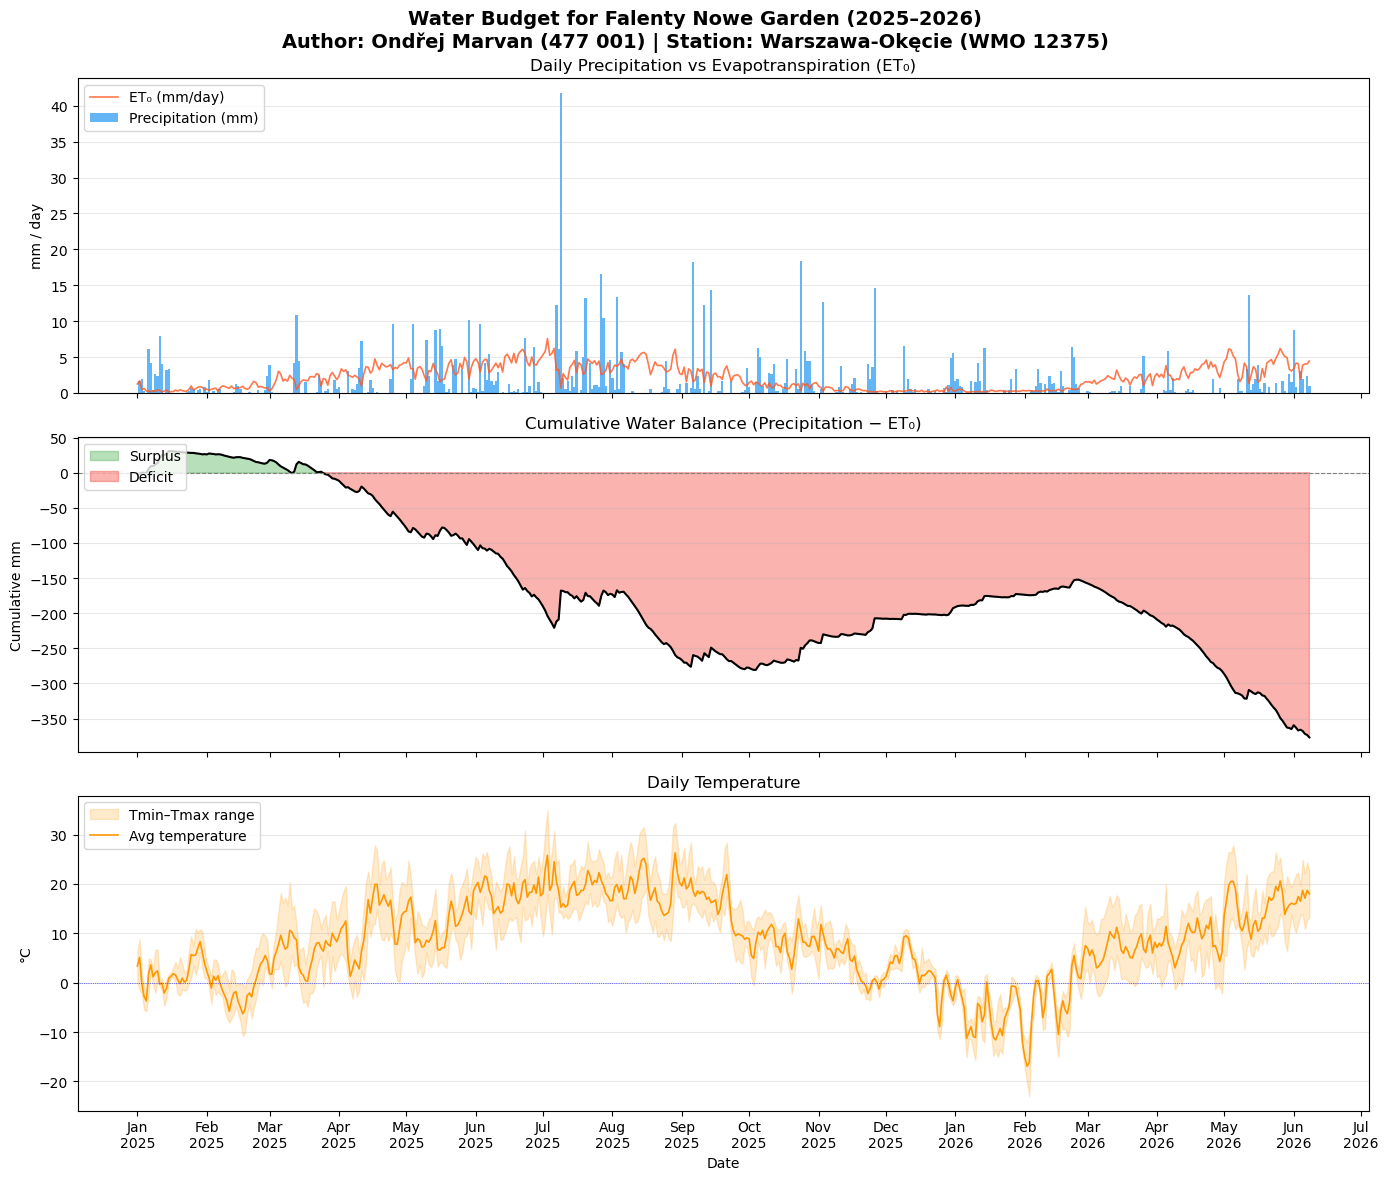

Charts saved to: output/water_budget_charts.png


In [11]:
# Make 3 charts on top of each other (stacked, sharing x-axis)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    "Water Budget for Falenty Nowe Garden (2025–2026)\n"
    f"Author: Ondřej Marvan (477 001) | Station: Warszawa-Okęcie (WMO 12375)",
    fontsize=14, fontweight="bold"
)

precip_col = "precip_om_mm" if "precip_om_mm" in df_final.columns else "precip_imgw_mm"

# Chart 1: blue bars for rain, orange line for evapotranspiration
ax1 = axes[0]
ax1.bar(df_final.index, df_final[precip_col], alpha=0.7,
        color="#2196F3", label="Precipitation (mm)", width=1)
ax1.plot(df_final.index, df_final["et0_mm"], color="#FF5722",
         linewidth=1.2, label="ET₀ (mm/day)", alpha=0.8)
ax1.set_ylabel("mm / day")
ax1.set_title("Daily Precipitation vs Evapotranspiration (ET₀)")
ax1.legend(loc="upper left")
ax1.grid(axis="y", alpha=0.3)

# Chart 2: cumulative water balance - GREEN if surplus, RED if deficit
ax2 = axes[1]
cum = df_final["cumulative_water_mm"]
ax2.fill_between(df_final.index, cum, 0,
                 where=cum >= 0, color="#4CAF50", alpha=0.4, label="Surplus")
ax2.fill_between(df_final.index, cum, 0,
                 where=cum < 0, color="#F44336", alpha=0.4, label="Deficit")
ax2.plot(df_final.index, cum, color="black", linewidth=1.5)
ax2.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)   # zero line
ax2.set_ylabel("Cumulative mm")
ax2.set_title("Cumulative Water Balance (Precipitation − ET₀)")
ax2.legend(loc="upper left")
ax2.grid(axis="y", alpha=0.3)

# Chart 3: temperature - shaded band shows min-max range, line shows average
ax3 = axes[2]
tavg_col = "tavg_om" if "tavg_om" in df_final.columns else "tavg_imgw"
if "tmax_om" in df_final.columns and "tmin_om" in df_final.columns:
    ax3.fill_between(df_final.index, df_final["tmin_om"], df_final["tmax_om"],
                     alpha=0.2, color="#FF9800", label="Tmin–Tmax range")
ax3.plot(df_final.index, df_final[tavg_col], color="#FF9800",
         linewidth=1.2, label="Avg temperature")
ax3.axhline(y=0, color="blue", linestyle=":", linewidth=0.5)   # freezing line
ax3.set_ylabel("°C")
ax3.set_xlabel("Date")
ax3.set_title("Daily Temperature")
ax3.legend(loc="upper left")
ax3.grid(axis="y", alpha=0.3)

# format the x-axis to show months nicely
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
# save the figure as a PNG
plt.savefig("output/water_budget_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved to: output/water_budget_charts.png")


## 8. Summary & Conclusions

**Author:** Ondřej Marvan (477 001)

### Tools Used (all required tools demonstrated)

| Tool | Section | How it was used |
|------|---------|-----------------|
| **Scrapy** | §1 | Spider crawls IMGW directory tree, downloads ZIPs (class Part 12 pattern: subprocess) |
| **Requests** | §3 | Fetches Open-Meteo JSON API + IMGW metadata page (class Parts 1-9 pattern) |
| **BeautifulSoup** | §3 & §4 | Parses IMGW HTML (find_all, get_text) + Meteostat rendered HTML (class pattern) |
| **lxml / XPath** | §3 | Extracts links from IMGW page using XPath (class Parts 7-8 pattern) |
| **Selenium** | §4 | Loads JS-rendered Meteostat page (class Parts 10-11: Options, ChromeDriverManager, WebDriverWait) |
| **Python Regex** | §2 & §4 | Parses CSV values, validates filenames, extracts metadata (class Parts 1-9: re.compile, re.match) |

### Data Attribution
- IMGW-PIB: "Źródłem pochodzenia danych jest Instytut Meteorologii i Gospodarki Wodnej – Państwowy Instytut Badawczy"
- Open-Meteo: CC BY 4.0 (Zippenfenig, 2023)
- Meteostat: CC BY-NC 4.0


In [12]:
# Final summary stats - the bottom line

print("=" * 65)
print("  FINAL PROJECT SUMMARY")
print("  Author: Ondřej Marvan (477 001)")
print("=" * 65)
print(f"  Location:    Falenty Nowe ({LAT}°N, {LON}°E)")
print(f"  Station:     {station_meta.get('station_name', 'Warszawa-Okęcie')}")
print(f"  Elevation:   {station_meta.get('elevation_m', ELEVATION)} m ASL")
print(f"  Period:      {df_final.index.min().date()} to {df_final.index.max().date()}")
print(f"  Days:        {len(df_final)}")
print(f"  Variables:   {len(df_final.columns)}")
print()
pcol = "precip_om_mm" if "precip_om_mm" in df_final.columns else "precip_imgw_mm"
print(f"  Total Precipitation:    {df_final[pcol].sum():.1f} mm")
print(f"  Total ET₀:              {df_final['et0_mm'].sum():.1f} mm")
print(f"  Net Water Balance:      {df_final['water_balance_mm'].sum():.1f} mm")
print(f"  Current Cumulative:     {df_final['cumulative_water_mm'].iloc[-1]:.1f} mm")
print()
# is the soil dry or wet overall?
status = "SURPLUS" if df_final['cumulative_water_mm'].iloc[-1] > 0 else "DEFICIT -> irrigate!"
print(f"  Garden Status: {status}")
print("=" * 65)
print(f"\n  Output: output/water_budget.csv")
print(f"  Charts: output/water_budget_charts.png")
print("\n--- Processing Complete ---")


  FINAL PROJECT SUMMARY
  Author: Ondřej Marvan (477 001)
  Location:    Falenty Nowe (52.135°N, 20.939°E)
  Station:     Warszawa-Okecie
  Elevation:   106 m ASL
  Period:      2025-01-01 to 2026-06-08
  Days:        524
  Variables:   11

  Total Precipitation:    735.6 mm
  Total ET₀:              1112.4 mm
  Net Water Balance:      -376.8 mm
  Current Cumulative:     -376.8 mm

  Garden Status: DEFICIT -> irrigate!

  Output: output/water_budget.csv
  Charts: output/water_budget_charts.png

--- Processing Complete ---
